# 2025-05-01 Network properties

## Summary

This notebooks includes the process to generate a network that will be analyzed using the 
`bipartite` package in R. 

## Data

- Our libraries, after removing reads not mapped at species level, grouping by species, and filtering those with less than 10 reads.

## Analysis


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from skbio.diversity import alpha_diversity, beta_diversity
from skbio import TreeNode
from skbio.stats.ordination import pcoa
from scipy.stats import kruskal
import networkx as nx

In [3]:
libraries = pd.read_json("../results/2025-04-21-mmseqs2-preprocess/products/library_species_count-ct10.json").rename(columns={'taxid': "gtdb_id"}).dropna(subset=['species'])

In [17]:
libraries.value_counts(['Host_taxon', 'gtdb_id', 'class']).reset_index().to_csv("../results/2025-05-01.bipartite-graphs/bip-network.host-bacteria.csv", sep=';')

In [18]:
libraries.value_counts(['Host_taxon', 'gtdb_id']).reset_index().pivot(index='Host_taxon', columns='gtdb_id', values='count').fillna(0.0).to_csv("../results/2025-05-01.bipartite-graphs/adj-mat.host-bacteria.csv", sep=';')

In [19]:
libraries.value_counts(['Host_taxon', 'gtdb_id', 'class']).reset_index().sample(n=1000).to_csv("../results/2025-05-01.bipartite-graphs/bip-network.host-bacteria.s1000.csv", sep=';')

In [22]:
libraries.value_counts(['Host_taxon', 'gtdb_id']).sample(n=10).reset_index().pivot(index='Host_taxon', columns='gtdb_id', values='count').fillna(0.0).to_csv("../results/2025-05-01.bipartite-graphs/adj-mat.host-bacteria.s100.csv", sep=';')

## Results

In [5]:
observed = pd.read_csv("../results/2025-05-01.bipartite-graphs/host-bacteria.observed.csv").set_index('Metric')
observed

,Value
Metric,
connectance,0.063318
NODF,15.342601


In [9]:
null = pd.read_csv("../results/2025-05-01.bipartite-graphs/host-bacteria.null.csv")
null

,connectance,NODF
0,0.063695,15.312548
1,0.063783,15.072136
2,0.063994,15.554196
3,0.063864,15.321956
4,0.063586,15.498889
...,...,...
995,0.063579,15.438427
996,0.063568,15.413830
997,0.063572,15.334484
998,0.063748,15.312741


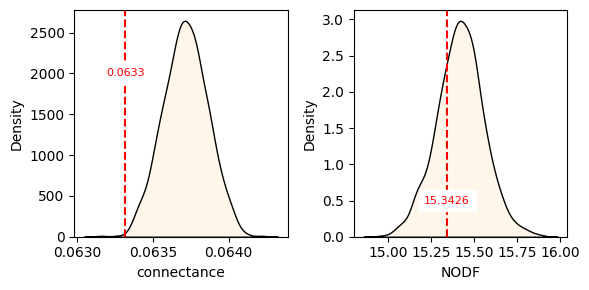

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
sns.kdeplot(null['connectance'], ax=ax[0], fill=True, color='navajowhite', edgecolor='black', linewidth=1.0)
ax[0].axvline(observed.loc['connectance']['Value'], color='red', linestyle='--')
ax[0].text(observed.loc['connectance']['Value'], 2000, f"{observed.loc['connectance']['Value']:.4f}", color='red', fontsize=8, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='white'))
sns.kdeplot(null['NODF'], ax=ax[1], fill=True, color='navajowhite', edgecolor='black', linewidth=1.0)
ax[1].axvline(observed.loc['NODF']['Value'], color='red', linestyle='--')
ax[1].text(observed.loc['NODF']['Value'], 0.5, f"{observed.loc['NODF']['Value']:.4f}", color='red', fontsize=8, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='white'))
fig.tight_layout()

In [48]:
np.sum(null['NODF'] > observed.loc['NODF']['Value']) / 1000.0

0.72

In [50]:
np.sum(null['connectance'] > observed.loc['connectance']['Value']) / 1000.0

0.998